In [1]:
#pip install seaborn

In [2]:
#pip install matplotlib

In [3]:
#pip install scikit-learn

In [4]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
import numpy as np

In [8]:
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split

In [9]:
#pip install imbalanced-learn


In [10]:
from imblearn.over_sampling import SMOTE

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

In [11]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [12]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score
import pickle

In [13]:
import warnings 
warnings.filterwarnings('ignore')

In [14]:
df=pd.read_csv('diabetes2.csv')

In [15]:
type(df)


pandas.DataFrame

In [16]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [17]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [19]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [20]:
df.shape

(768, 9)

In [21]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [23]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [24]:
df=df.drop_duplicates()

In [25]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [26]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [27]:

df.isna().sum()                 
df=df.drop_duplicates()            


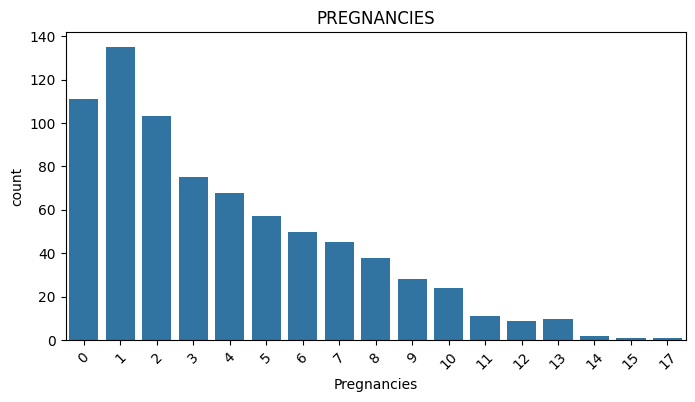

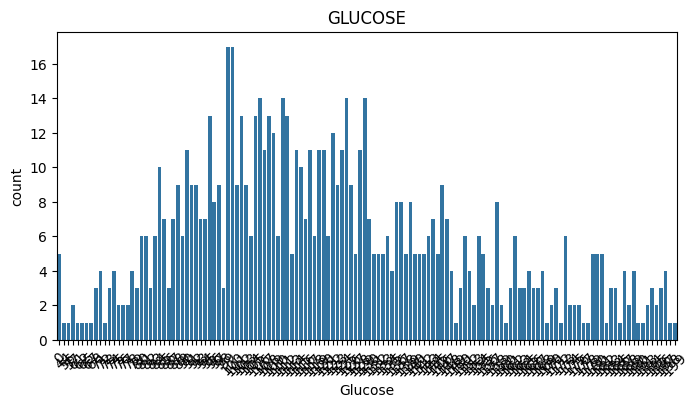

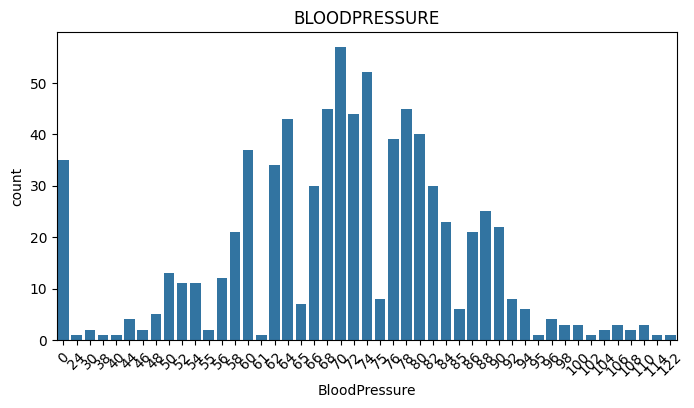

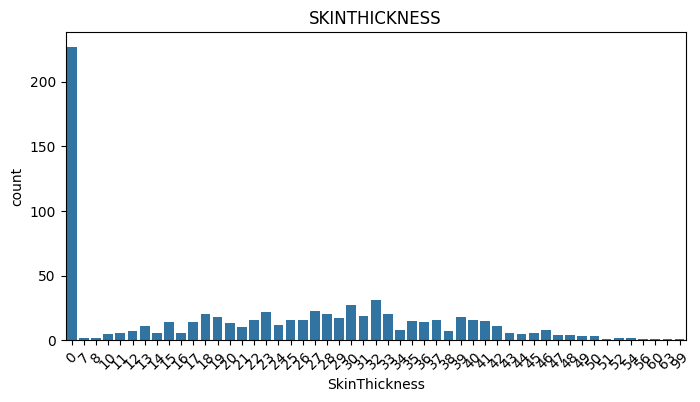

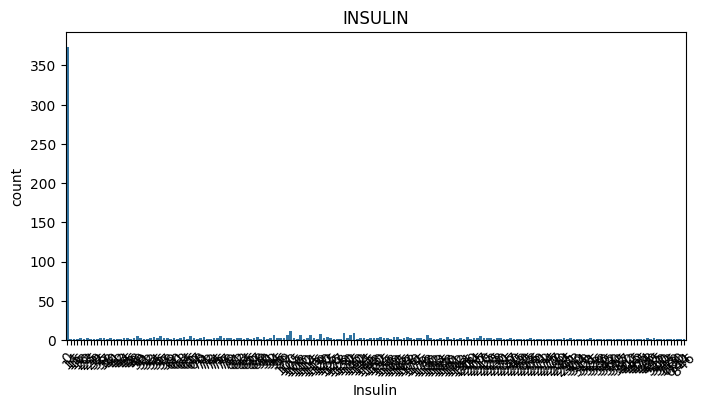

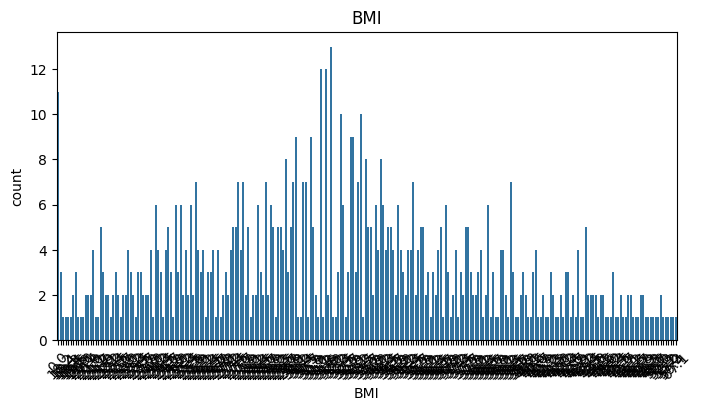

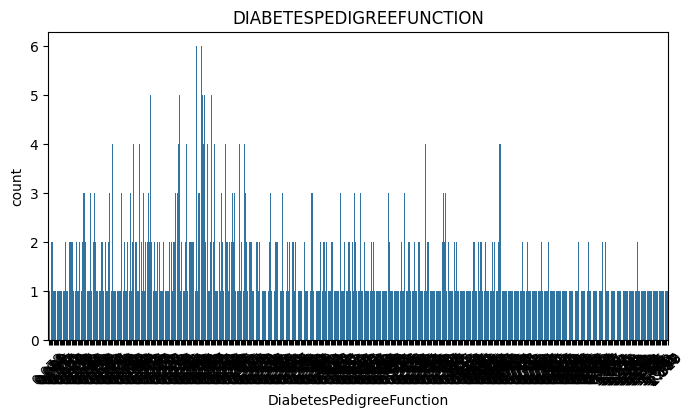

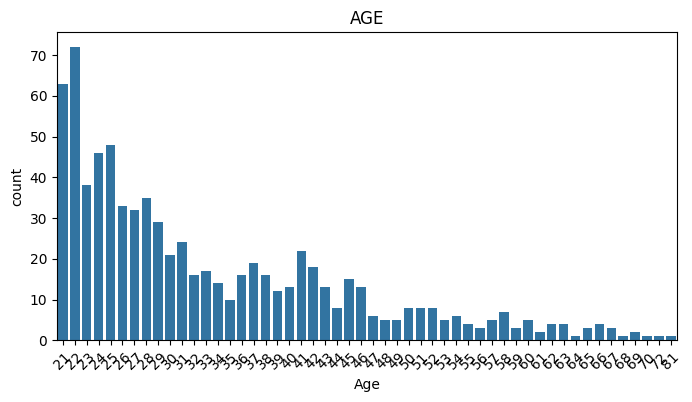

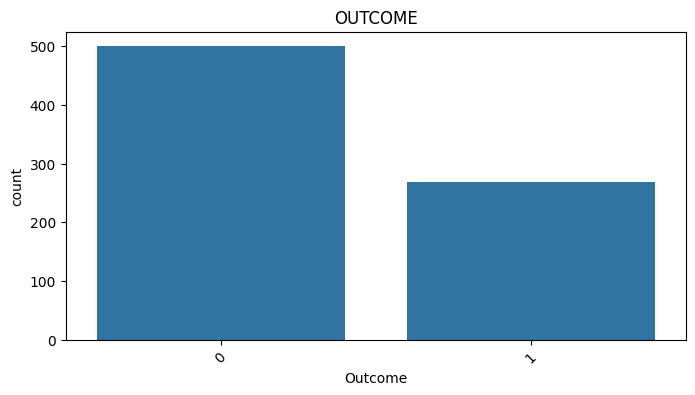

In [59]:
for col in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df,x=col)
    plt.title(col.upper())
    plt.xticks(rotation=45)
    plt.show()

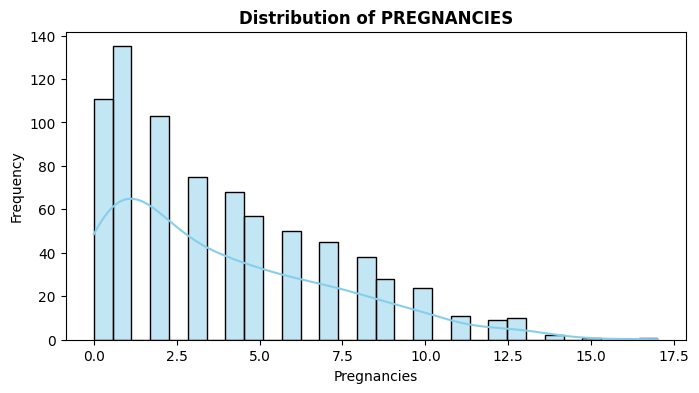

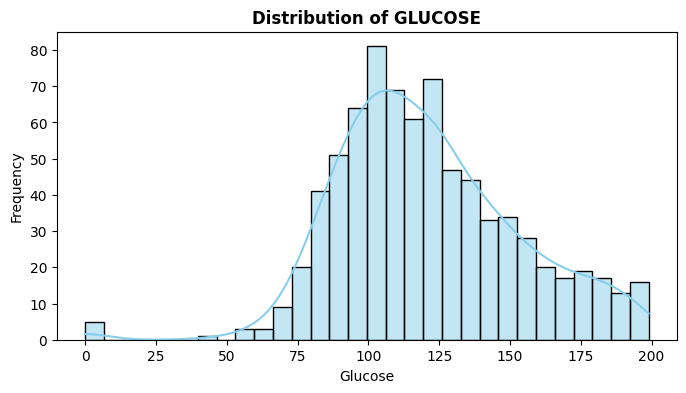

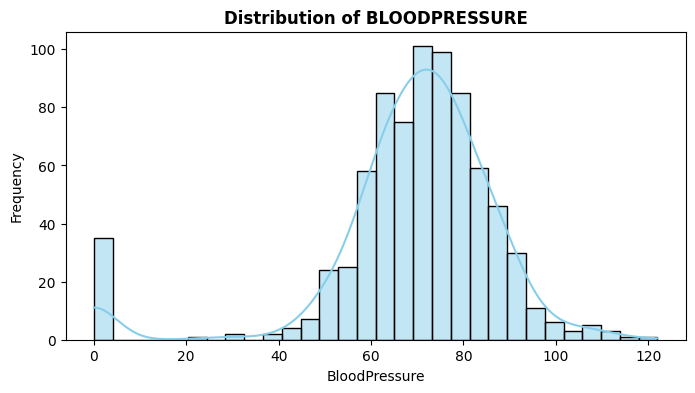

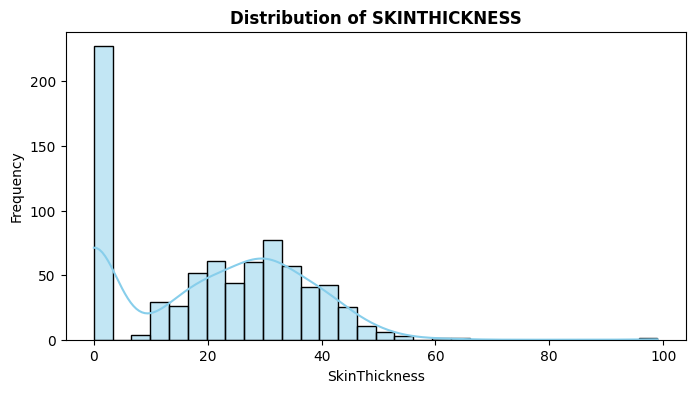

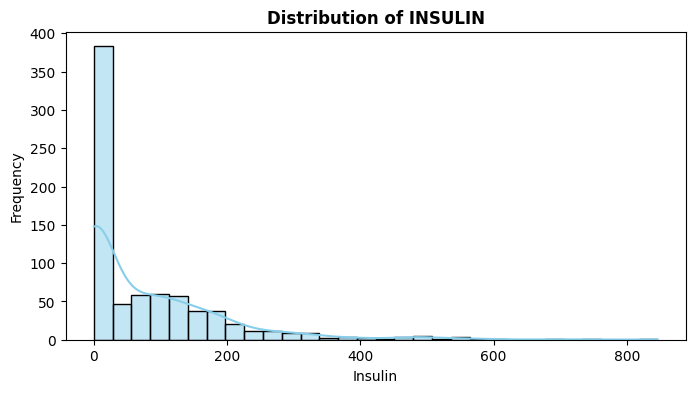

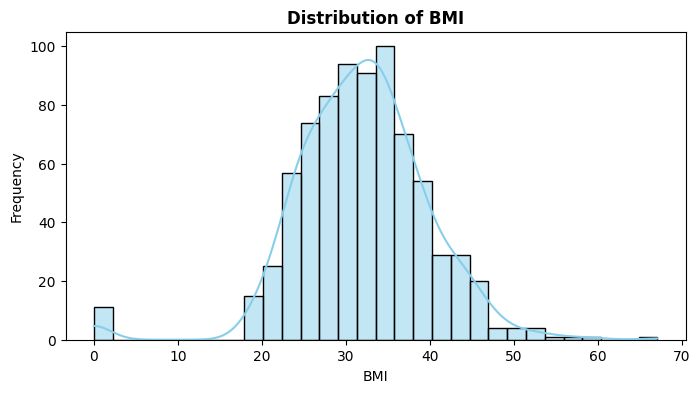

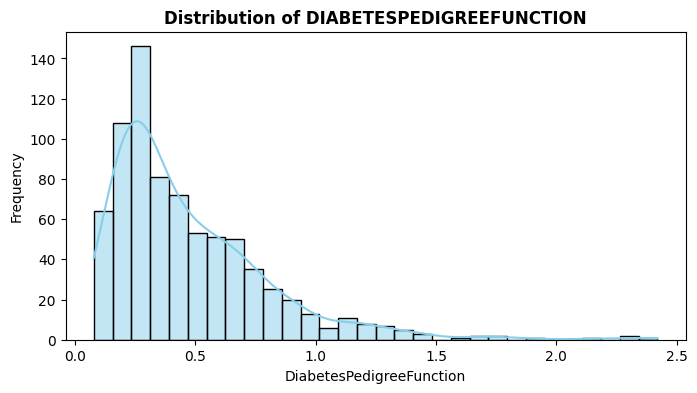

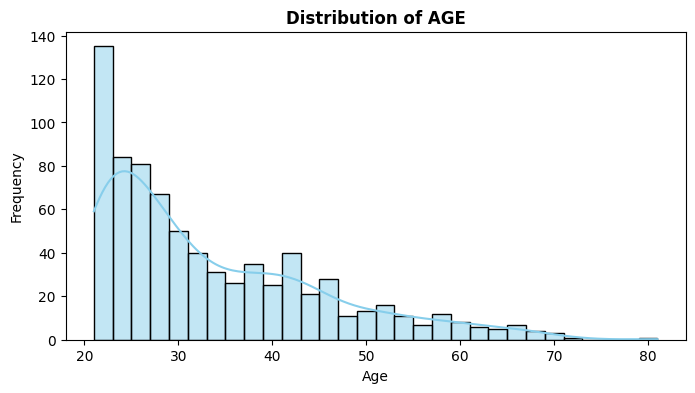

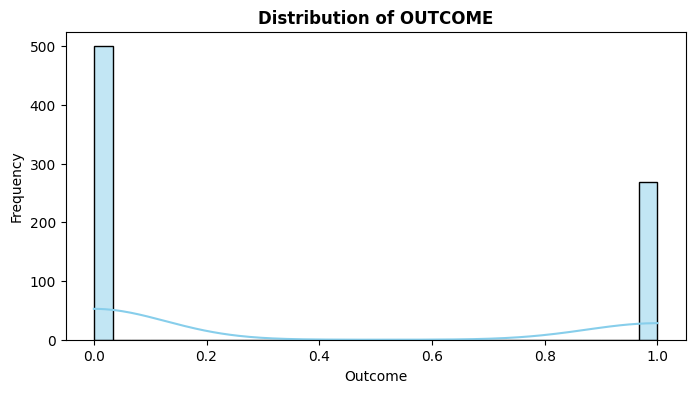

In [63]:
# 1. Select only numerical columns (integers and floats)
num_df = df.select_dtypes(include=["number"])

# 2. Loop through each numerical column
for col in num_df.columns:
    
    plt.figure(figsize=(8, 4))
    
    # Create the histogram with a density curve
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        color="skyblue"
    )
    
    # Styling the plot
    plt.title(f"Distribution of {col.upper()}", fontsize=12, weight="bold")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

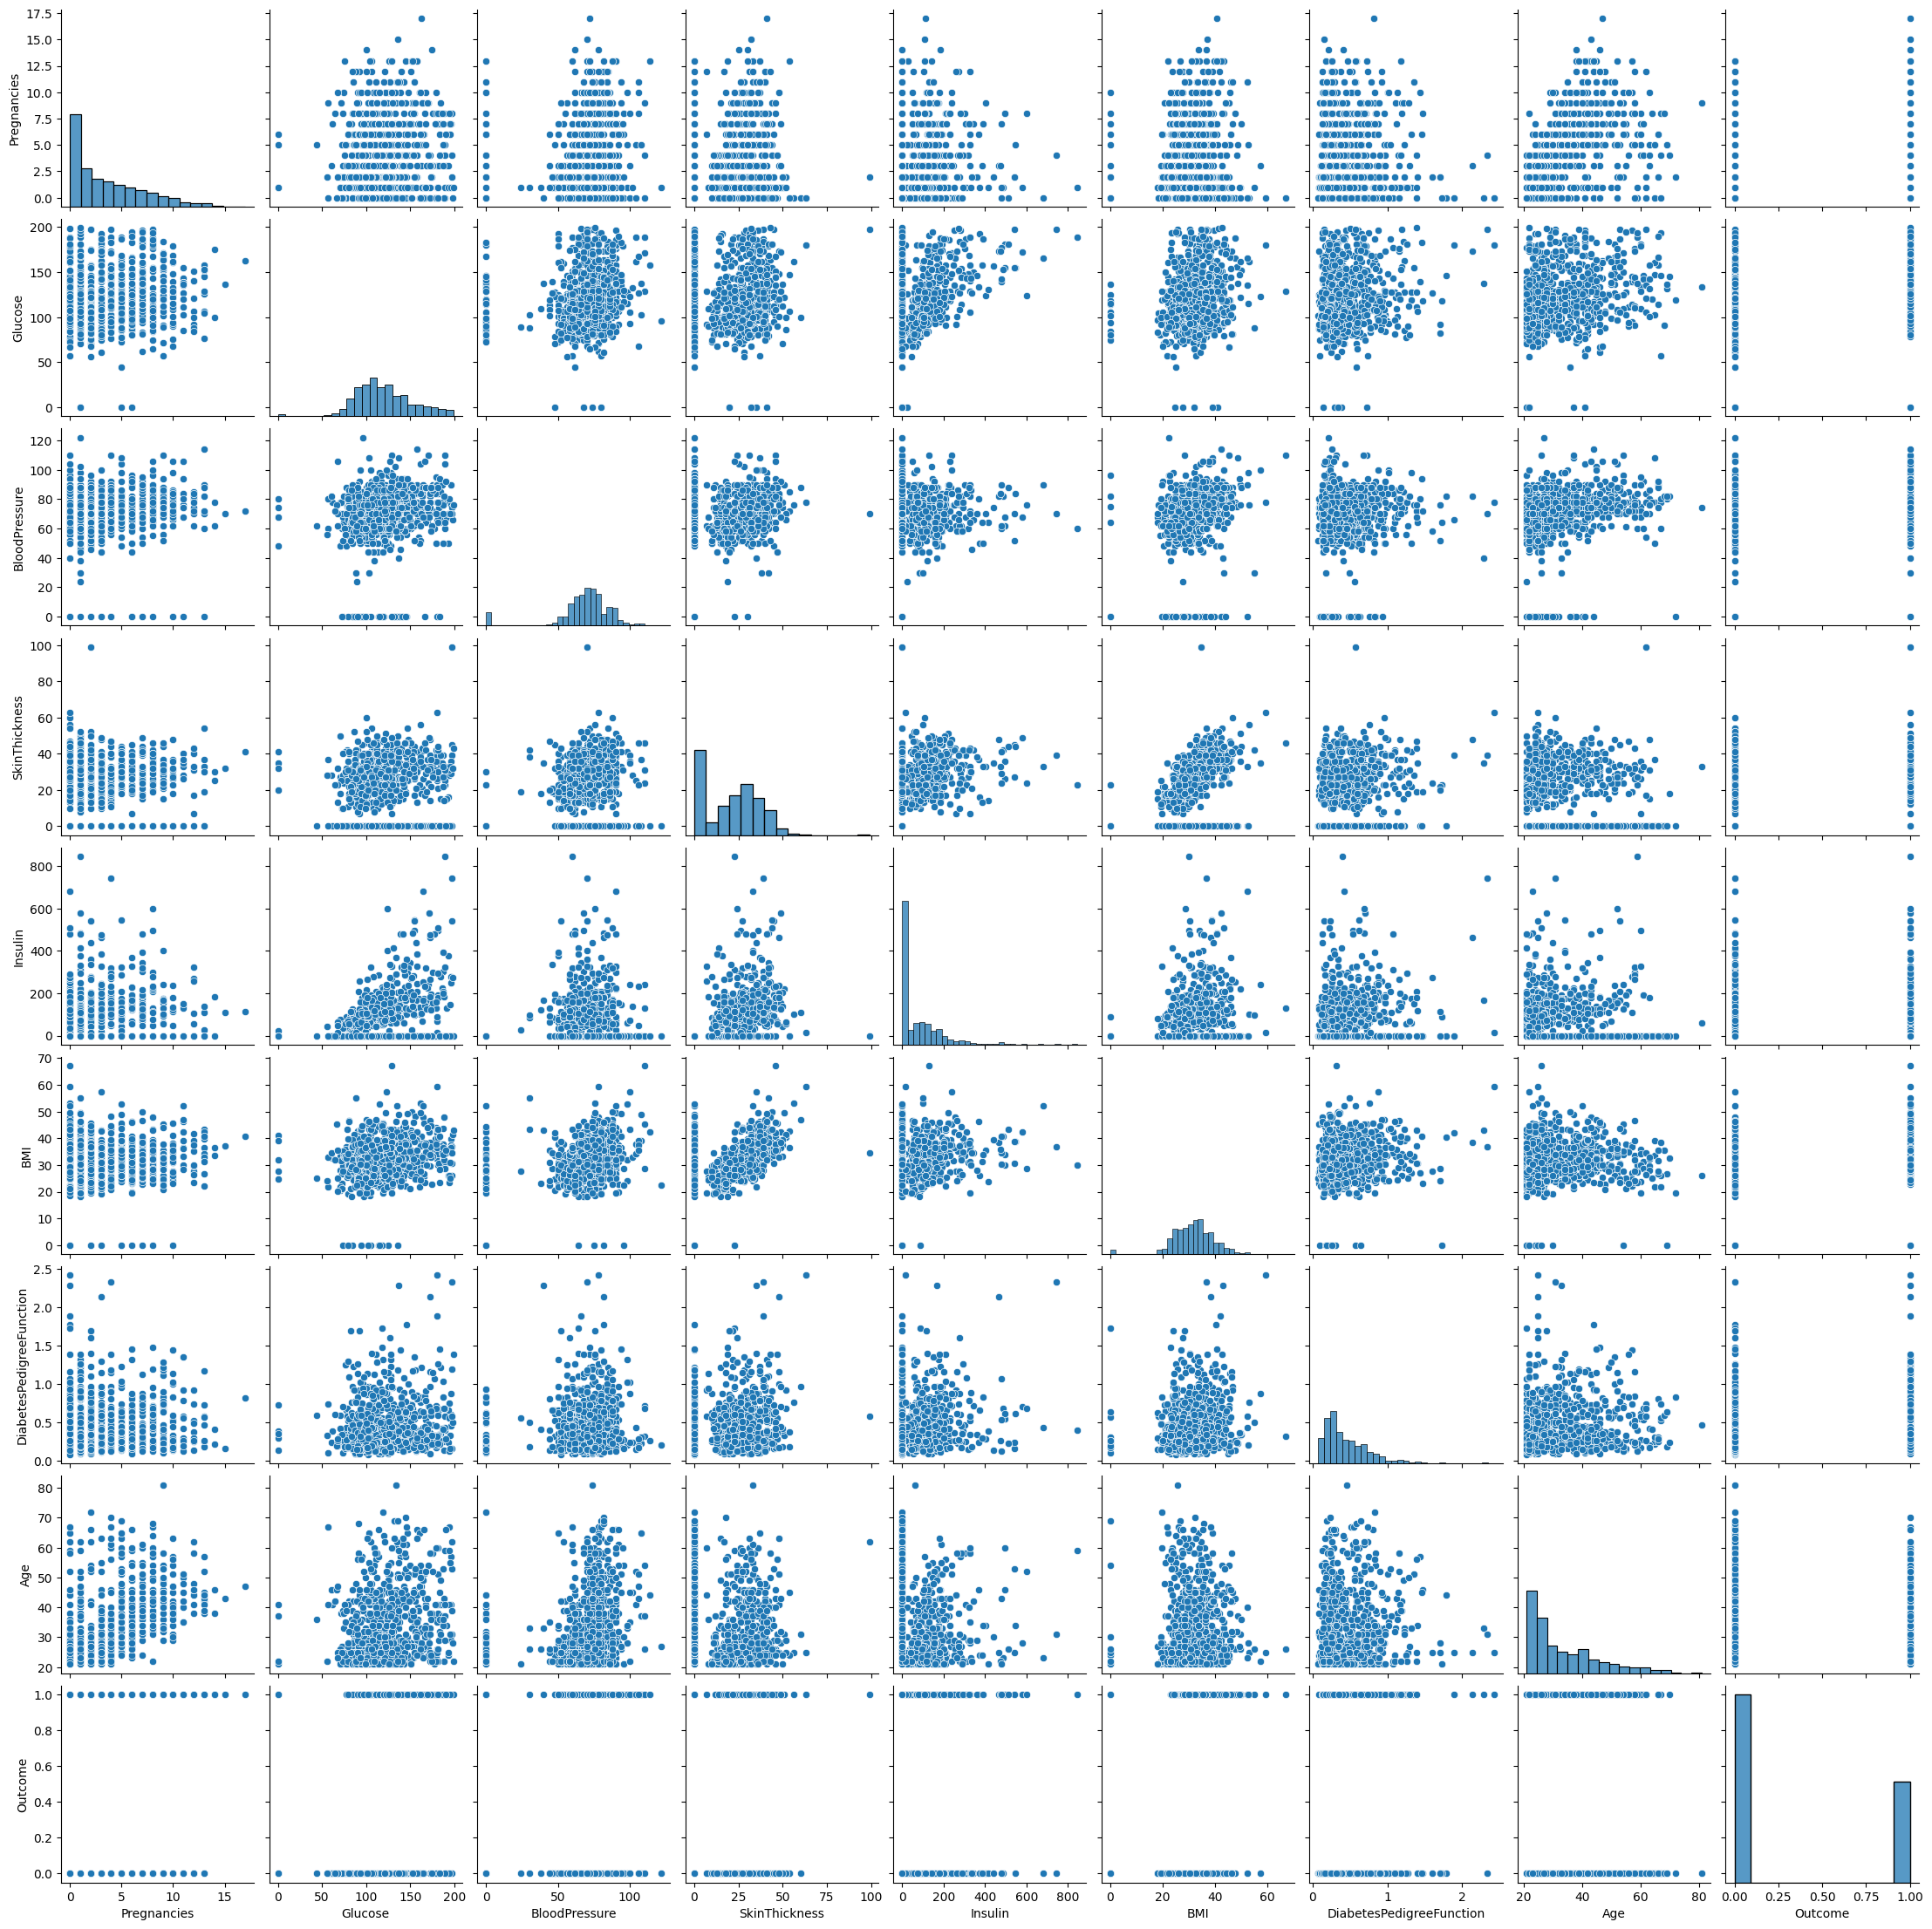

In [64]:
sns.pairplot(df)

In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

<Axes: >

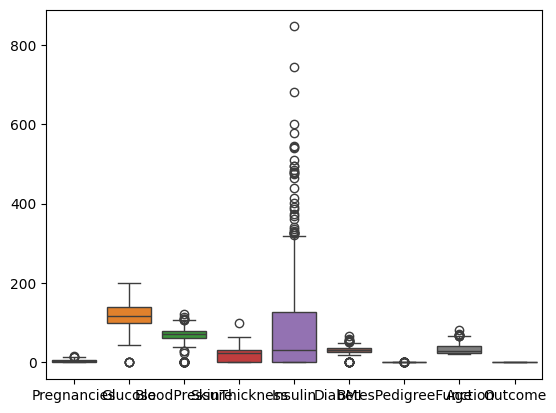

In [30]:
plt.Figure(figsize=(15,5))
sns.boxplot(df)

In [31]:
#pip install feature_engine

In [32]:
from feature_engine.outliers import Winsorizer
winsor= Winsorizer(capping_method='mad',tail='both',fold=1.5)

<Axes: >

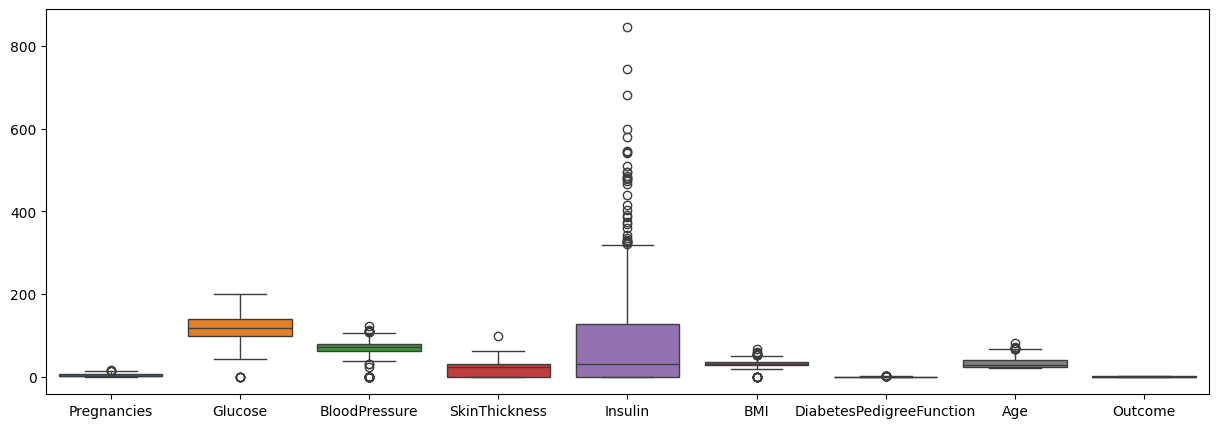

In [33]:
plt.figure(figsize=(15,5))
sns.boxplot(df)

In [34]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap the entire dataframe
df2=df.clip(lower=lower_bound, upper=upper_bound, axis=1)

<Axes: >

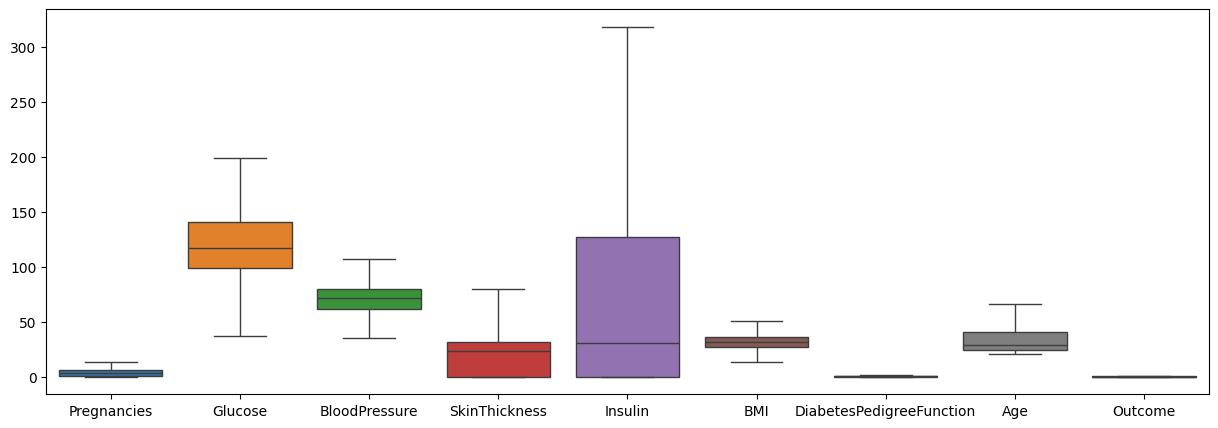

In [35]:
plt.figure(figsize=(15,5))
sns.boxplot(df2)

In [36]:
x=df2.drop('Outcome',axis=1)
y=df2['Outcome']

In [37]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72,35,0.0,33.6,0.627,50.0
1,1.0,85.0,66,29,0.0,26.6,0.351,31.0
2,8.0,183.0,64,0,0.0,23.3,0.672,32.0
3,1.0,89.0,66,23,94.0,28.1,0.167,21.0
4,0.0,137.0,40,35,168.0,43.1,1.200,33.0
...,...,...,...,...,...,...,...,...
763,10.0,101.0,76,48,180.0,32.9,0.171,63.0
764,2.0,122.0,70,27,0.0,36.8,0.340,27.0
765,5.0,121.0,72,23,112.0,26.2,0.245,30.0
766,1.0,126.0,60,0,0.0,30.1,0.349,47.0


In [38]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [39]:
q=MinMaxScaler()
x=q.fit_transform(x)

In [40]:
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
x_train.shape,x_test.shape

((537, 8), (231, 8))

In [41]:
y_train.shape,y_test.shape

((537,), (231,))

In [42]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

Model Building

   KNeighborsClassifier()
********************************************************************************************
 accuracy_test= 77.92207792207793
accuracy_train= 79.88826815642457
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       146
           1       0.75      0.60      0.67        85

    accuracy                           0.78       231
   macro avg       0.77      0.74      0.75       231
weighted avg       0.78      0.78      0.77       231



   RandomForestClassifier()
********************************************************************************************
 accuracy_test= 80.95238095238095
accuracy_train= 100.0
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       146
           1       0.79      0.66      0.72        85

    accuracy                           0.81       231
   macro avg       0.80      0.78      0.79       231
weighted avg       0.81      0.81  

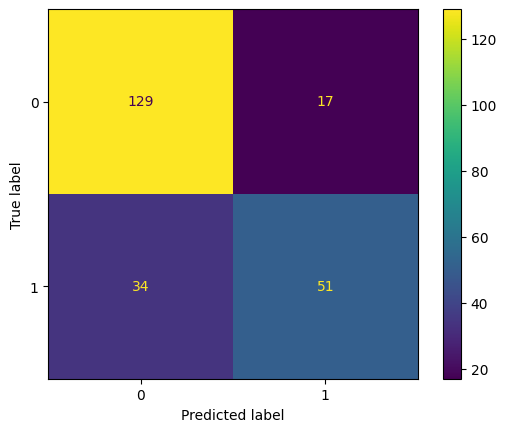

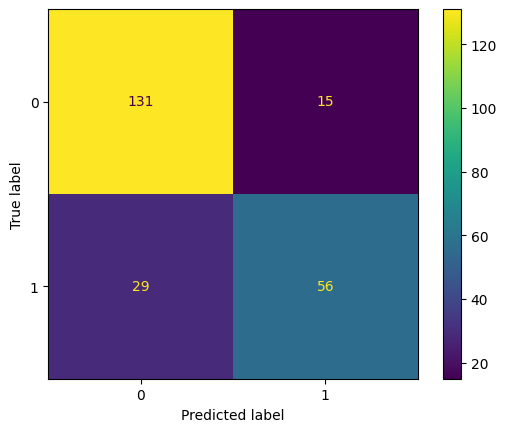

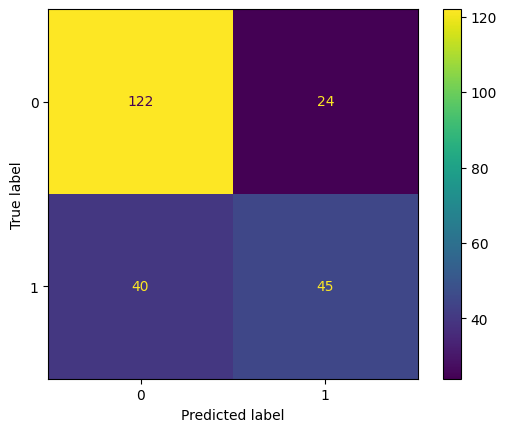

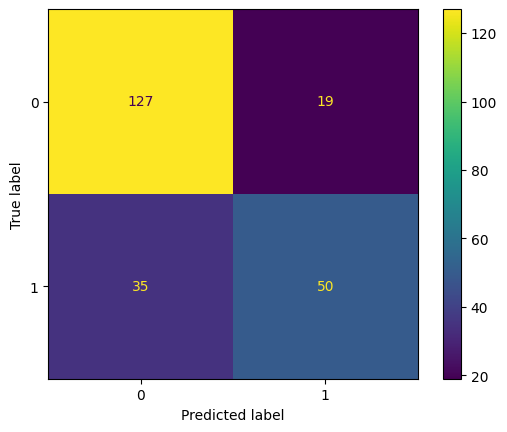

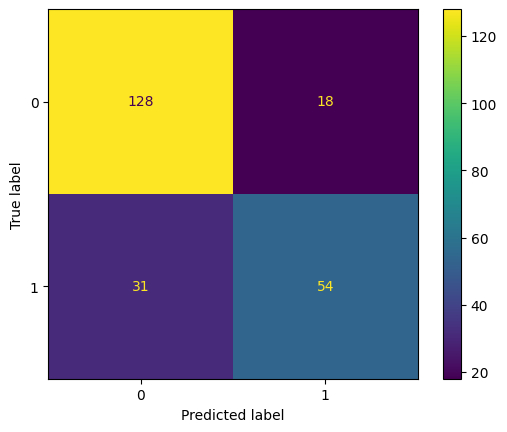

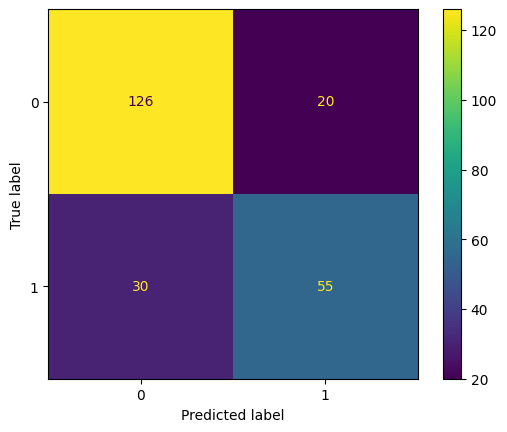

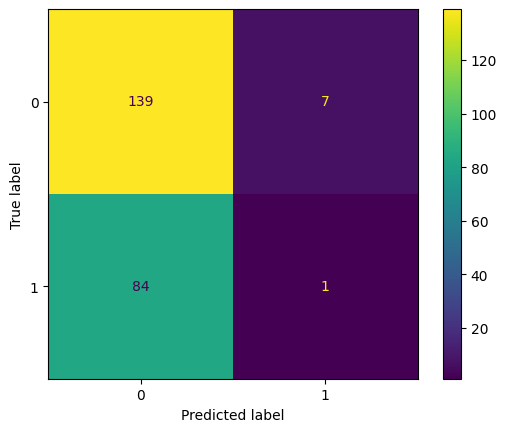

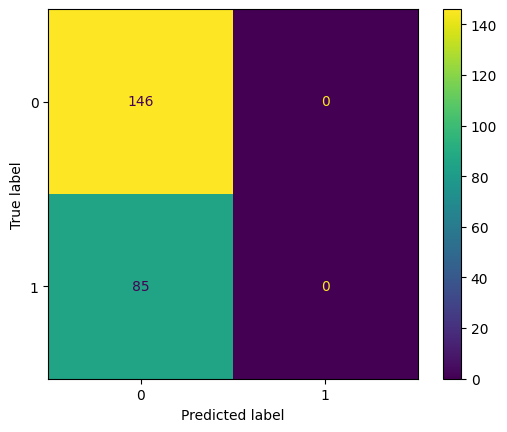

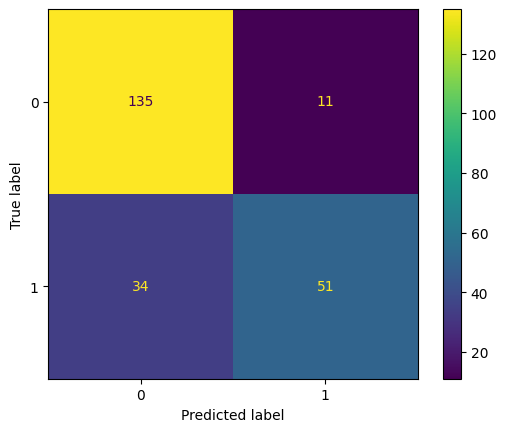

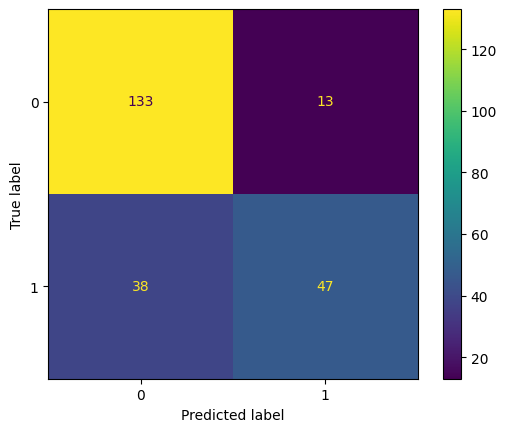

In [43]:
k=KNeighborsClassifier()
r=RandomForestClassifier()
d=DecisionTreeClassifier()
a=AdaBoostClassifier()
h=GradientBoostingClassifier()
g=GaussianNB()
b=BernoulliNB()
m=MultinomialNB() 
v=SVC()
l=LogisticRegression()


model=[k,r,d,a,h,g,b,m,v,l]

for i in model:
    print('  ',i)
    print('********************************************************************************************')
    i.fit(x_train,y_train)
    y_pred=i.predict(x_test)
    y_pred_train=i.predict(x_train)
    print(' accuracy_test=', accuracy_score(y_test,y_pred)*100)
    print('accuracy_train=', accuracy_score(y_train,y_pred_train)*100)
    print(classification_report(y_test,y_pred))
    print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
    
    print()
    print()

Cross Validation

In [44]:
from sklearn.model_selection import cross_val_score
print("cross vali score for all models on training data:")
for i in model:
    print("                 ",i.__class__.__name__)
    print("***********************************************************************************")
    score = cross_val_score(i,x,y,cv=5,scoring='accuracy',n_jobs=-1)
    print(f"cv accuracy scores:{score}")
    print(f"Mean Accuracy:{np.mean(score)*100:2f}%\n")

cross vali score for all models on training data:
                  KNeighborsClassifier
***********************************************************************************
cv accuracy scores:[0.75974026 0.71428571 0.73376623 0.78431373 0.75816993]
Mean Accuracy:75.005517%

                  RandomForestClassifier
***********************************************************************************
cv accuracy scores:[0.77922078 0.72077922 0.77922078 0.83006536 0.76470588]
Mean Accuracy:77.479840%

                  DecisionTreeClassifier
***********************************************************************************
cv accuracy scores:[0.7012987  0.62337662 0.66883117 0.77124183 0.7254902 ]
Mean Accuracy:69.804770%

                  AdaBoostClassifier
***********************************************************************************
cv accuracy scores:[0.74675325 0.72727273 0.75324675 0.83660131 0.75816993]
Mean Accuracy:76.440879%

                  GradientBoostingClassifier
***

Hypertuning

In [45]:
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning for RandomForest ... ")
param_grid = {'n_estimators': [50, 100, 200],'max_depth': [None, 10, 20, 30],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

rf = RandomForestClassifier(random_state=1)
# Using n_iter=5 and cv=3 to keep tuning time reasonable. Increase for better results.
grid_search = GridSearchCV(
estimator=rf, param_grid=param_grid,
cv=3, scoring='accuracy', n_jobs =- 1
) 

grid_search.fit(x_train, y_train)

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_*100:.2f}%")

R=grid_search.best_estimator_
y_pred_r=R.predict(x_test)
y_pred_r

Starting Hyperparameter Tuning for RandomForest ... 
Best Parameters found: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 75.23%


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0])

In [46]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [47]:
print(x.shape)

(768, 8)


In [48]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [49]:
y_new = R.predict(q.transform([[6,148,72,35,0,33.6,0.627,50]]))

if y_new == 0:
    print("Non-diabetic")
else:
    print("Diabetic")

Diabetic


In [50]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [51]:
# Example: Diabetes dataset prediction script

# Assume you already trained a model R with preprocessing pipeline m
# and label encoders le1, le2, etc. (if needed)

# Collect user input
pregnancies = int(input("Enter number of Pregnancies: "))
glucose = int(input("Enter Glucose level: "))
blood_pressure = int(input("Enter Blood Pressure: "))
skin_thickness = int(input("Enter Skin Thickness: "))
insulin = int(input("Enter Insulin level: "))
bmi = float(input("Enter BMI: "))
diabetes_pedigree = float(input("Enter Diabetes Pedigree Function: "))
age = int(input("Enter Age: "))

# Transform and predict
y_new = R.predict(
    q.transform([[pregnancies, glucose, blood_pressure, skin_thickness,
                  insulin, bmi, diabetes_pedigree, age]])
)

# Output result
if y_new[0] == 0:
    print("Non-Diabetic")
else:
    print("Diabetic")


Non-Diabetic


Visualization

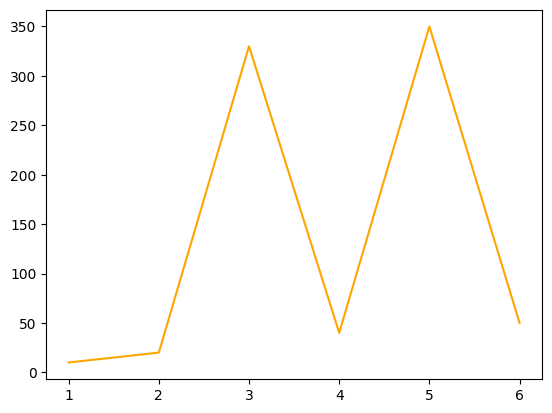

In [52]:
x = [1, 2, 3, 4, 5, 6] 
y = [10, 20, 330, 40, 350, 50]
plt.plot(x,y,color='orange')

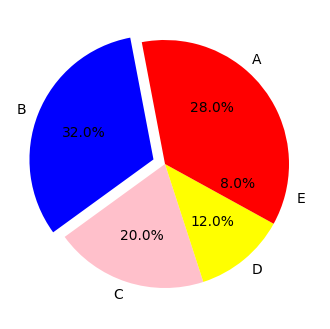

In [53]:
cate=['A','B','C','D','E']
value=[7,8,5,3,2]
c=['red','blue','pink','yellow']
plt.figure(figsize=(4,5))
plt.pie(value,labels=cate,colors=c,explode=[0,0.1,0,0,0],autopct='%.1f%%')
plt.show()

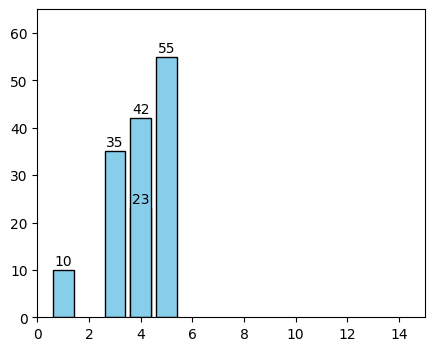

In [54]:
x=[1,4,3,4,5]
y=[10,23,35,42,55]
plt.figure(figsize=(5,4))
plt.bar(x,y,color='skyblue',edgecolor='black')
for i,j in enumerate(y):
    plt.text(x[i],j+1,str(j),ha='center')
plt.ylim(0,max(y)+10)
plt.xlim(0,max(x)+10)
plt.show()

In [55]:
import pickle

In [56]:
pickle.dump(r,open('diabetes_model.save','wb'))
pickle.dump(m,open('diabetes_scaler.save','wb'))
